# Interpretability: what is the classifier actually keying on?

Uses Captum (Integrated Gradients + Saliency) to attribute each prediction back to input tokens, for both:

- **length_controlled** model — the main classifier, pairs truncated to equal length
- **raw** model — trained on uncontrolled lengths, kept to demonstrate the length-shortcut

**Prerequisite**: download the two checkpoint folders trained in `03_finetune_distilbert.ipynb` from Google Drive (`ai_text_detection_checkpoints/{length_controlled,raw}/final/`) into `results/checkpoints/{length_controlled,raw}/final/` locally before running this notebook. Inference-only work like this is fast on CPU — no GPU needed here.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
from transformers import DistilBertForSequenceClassification

from interpret import get_word_attributions, top_k_tokens
from model import load_tokenizer

CHECKPOINTS_DIR = Path.cwd().parent / 'results' / 'checkpoints'
LENGTH_CONTROLLED_DIR = CHECKPOINTS_DIR / 'length_controlled' / 'final'
RAW_DIR = CHECKPOINTS_DIR / 'raw' / 'final'

for d in (LENGTH_CONTROLLED_DIR, RAW_DIR):
    print(d, '->', 'found' if d.exists() else 'MISSING — download from Colab/Drive first')

D:\Documents\Studies\DeepLearning\results\checkpoints\length_controlled\final -> found
D:\Documents\Studies\DeepLearning\results\checkpoints\raw\final -> found


## Load both checkpoints and a few held-out test examples

Each checkpoint's own `test_split.parquet` (saved during training) is used, so
each model is inspected on the examples it was actually evaluated on.

In [2]:
def load_checkpoint(final_dir):
    tokenizer = load_tokenizer(str(final_dir))
    model = DistilBertForSequenceClassification.from_pretrained(str(final_dir))
    test_df = pd.read_parquet(final_dir / 'test_split.parquet')
    return model, tokenizer, test_df


lc_model, lc_tokenizer, lc_test_df = load_checkpoint(LENGTH_CONTROLLED_DIR)
raw_model, raw_tokenizer, raw_test_df = load_checkpoint(RAW_DIR)

print('length_controlled test set:', lc_test_df.shape)
print('raw test set:', raw_test_df.shape)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

length_controlled test set: (4998, 6)
raw test set: (4998, 6)


## Per-example attributions

Top-attributed tokens (by absolute Integrated Gradients score) for a handful
of correctly-classified human and AI examples from each model.

In [3]:
def show_examples(model, tokenizer, test_df, n_per_label=3, method='ig', seed=0):
    for label, name in [(0, 'HUMAN'), (1, 'AI')]:
        sample = test_df[test_df['label'] == label].sample(n=n_per_label, random_state=seed)
        for _, row in sample.iterrows():
            tokens, scores, pred, prob = get_word_attributions(model, tokenizer, row['text'], method=method)
            correct = 'correct' if pred == label else 'WRONG'
            print(f"\n=== true={name} pred={pred} (p={prob:.2f}, {correct}) ===")
            print('text:', row['text'][:200])
            print('top tokens:', top_k_tokens(tokens, scores, k=8))


print('##### length_controlled model #####')
show_examples(lc_model, lc_tokenizer, lc_test_df)

##### length_controlled model #####



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: More eyes for reading and sifting through laws and documents .
top tokens: [('more', np.float32(0.5161309)), ('eyes', np.float32(-0.3374963)), ('through', np.float32(0.33191168)), ('reading', np.float32(-0.32953712)), ('for', np.float32(0.2872327)), ('documents', np.float32(-0.19776616)), ('and', np.float32(0.17271765)), ('and', np.float32(0.17050223))]



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: If I give you a quantity of flour , sugar , cinnamon , eggs , and chocolate chips , and take the same quantity of these ingredients for myself , we can both make cookies , but the cookies wo n't come 
top tokens: [('.', np.float32(0.2087632)), ('if', np.float32(0.19387071)), (',', np.float32(0.17981486)), ('of', np.float32(0.17333148)), (',', np.float32(0.14311522)), ('for', np.float32(0.08321563)), ("'", np.float32(0.077188864)), ("'", np.float32(0.07126574))]



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: There is change , we have elections every two years ( four for president ) Every two years we vote on the entire house of representatives ( half of congress , the legislative - lawmaking branch of gov
top tokens: [('.', np.float32(0.26838896)), ('there', np.float32(0.19740772)), (',', np.float32(0.13293022)), ('.', np.float32(0.12379281)), ('of', np.float32(0.09906669)), ('the', np.float32(-0.096542135)), (',', np.float32(0.08831775)), ('-', np.float32(0.08514367))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Section 4 of the Voting Rights Act (VRA) is a key provision that determines which states and localities are subject to the preclearance requirement in Section 5 of the VRA. Preclearance is a process i
top tokens: [('no', np.float32(0.25565985)), ('and', np.float32(0.25232065)), ('case', np.float32(0.23329026)), ('reflected', np.float32(0.21270823)), ('v', np.float32(0.19253655)), ('which', np.float32(0.17795542)), ('or', np.float32(0.177627)), ('process', np.float32(0.16536255))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Evolution doesn't work by making humans perceive certain things as more attractive. Rather, evolution works by favoring traits that help individuals survive and reproduce. In other words, evolution he
top tokens: [('because', np.float32(0.40904713)), ('.', np.float32(-0.3954343)), ('one', np.float32(0.34801728)), ('is', np.float32(0.33384702)), ('words', np.float32(0.24371912)), ('other', np.float32(0.22991714)), ('reason', np.float32(0.2226112)), ('health', np.float32(0.20332755))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Eating organic food can have some benefits for your health, but it is not necessarily "much better" for everyone. The main difference between organic and non-organic food is the way it is grown and pr
top tokens: [('the', np.float32(0.4542557)), ('to', np.float32(0.29512832)), ('aim', np.float32(0.22819148)), ('the', np.float32(0.2274812)), ('"', np.float32(0.2145402)), ('"', np.float32(0.2046988)), ('for', np.float32(0.1918991)), ('everyone', np.float32(0.17757756))]


In [4]:
print('##### raw (length-uncontrolled) model #####')
show_examples(raw_model, raw_tokenizer, raw_test_df)

##### raw (length-uncontrolled) model #####



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: More eyes for reading and sifting through laws and documents .
top tokens: [('for', np.float32(0.7699724)), ('more', np.float32(0.7164394)), ('documents', np.float32(-0.3985563)), ('reading', np.float32(-0.3960072)), ('laws', np.float32(-0.3819576)), ('through', np.float32(0.37451926)), ('.', np.float32(0.34819254)), ('and', np.float32(0.23418793))]



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: If I give you a quantity of flour , sugar , cinnamon , eggs , and chocolate chips , and take the same quantity of these ingredients for myself , we can both make cookies , but the cookies wo n't come 
top tokens: [('was', np.float32(-0.07051541)), ('i', np.float32(0.059582837)), ('.', np.float32(0.05659073)), ('.', np.float32(0.05433243)), ("'", np.float32(0.05187389)), (',', np.float32(0.048256498)), (',', np.float32(0.045707967)), ('.', np.float32(0.045149446))]



=== true=HUMAN pred=0 (p=1.00, correct) ===
text: There is change , we have elections every two years ( four for president ) Every two years we vote on the entire house of representatives ( half of congress , the legislative - lawmaking branch of gov
top tokens: [("'", np.float32(0.22246268)), ('.', np.float32(0.06394194)), ('is', np.float32(0.051726207)), (',', np.float32(0.05004736)), ('n', np.float32(0.04964795)), ('(', np.float32(0.047732033)), (')', np.float32(0.04646296)), (',', np.float32(0.046158418))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Section 4 of the Voting Rights Act (VRA) is a key provision that determines which states and localities are subject to the preclearance requirement in Section 5 of the VRA. Preclearance is a process i
top tokens: [('rather', np.float32(0.42646277)), ('effectively', np.float32(0.33515695)), ('simple', np.float32(0.20943433)), ('states', np.float32(-0.17065182)), ('unconstitutional', np.float32(0.17000932)), (',', np.float32(0.16267736)), (',', np.float32(0.15624031)), ('##able', np.float32(0.14532815))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Evolution doesn't work by making humans perceive certain things as more attractive. Rather, evolution works by favoring traits that help individuals survive and reproduce. In other words, evolution he
top tokens: [('example', np.float32(0.47592294)), ('.', np.float32(-0.40253156)), ('for', np.float32(0.35101768)), ('ultimately', np.float32(0.25878316)), ('important', np.float32(0.22834866)), ('is', np.float32(0.21269688)), (',', np.float32(0.21198979)), ('to', np.float32(0.2104785))]



=== true=AI pred=1 (p=1.00, correct) ===
text: Eating organic food can have some benefits for your health, but it is not necessarily "much better" for everyone. The main difference between organic and non-organic food is the way it is grown and pr
top tokens: [('one', np.float32(0.63921756)), ('whenever', np.float32(0.41430426)), (',', np.float32(0.22800027)), ('for', np.float32(0.22704096)), ('example', np.float32(0.21549158)), ('food', np.float32(-0.21048683)), ('possible', np.float32(0.20609666)), ('potential', np.float32(0.1622747))]


## Aggregate vocabulary signal

Average attribution per token across many test examples, separately for each
model, to see whether the same words/punctuation show up systematically
(vocabulary/rhythm signal) rather than one-off artifacts.

In [5]:
from collections import defaultdict


def aggregate_token_attributions(model, tokenizer, test_df, n_samples=100, method='ig', seed=0):
    sample = test_df.sample(n=min(n_samples, len(test_df)), random_state=seed)
    sums = defaultdict(float)
    counts = defaultdict(int)
    for _, row in sample.iterrows():
        tokens, scores, _, _ = get_word_attributions(model, tokenizer, row['text'], method=method)
        sign = 1 if row['label'] == 1 else -1  # orient toward "pushes prediction toward AI"
        for tok, score in zip(tokens, scores):
            if tok in ('[CLS]', '[SEP]', '[PAD]'):
                continue
            sums[tok] += sign * score
            counts[tok] += 1
    avg = {tok: sums[tok] / counts[tok] for tok in sums if counts[tok] >= 3}
    return pd.Series(avg).sort_values()


lc_agg = aggregate_token_attributions(lc_model, lc_tokenizer, lc_test_df, n_samples=100)
print('length_controlled — tokens pushing toward HUMAN:')
print(lc_agg.head(15))
print('\nlength_controlled — tokens pushing toward AI:')
print(lc_agg.tail(15))

length_controlled — tokens pushing toward HUMAN:
##ly        -0.092946
'           -0.074123
generally   -0.071658
years       -0.065320
##l         -0.062675
.           -0.061131
had         -0.059073
was         -0.057971
its         -0.045695
him         -0.043658
her         -0.043125
##ing       -0.042646
un          -0.041222
trade       -0.040407
over        -0.039798
dtype: float32

length_controlled — tokens pushing toward AI:
called         0.165777
legal          0.173985
chemicals      0.182413
depending      0.182747
designed       0.187257
example        0.190912
sure           0.191461
known          0.212763
electricity    0.223245
caused         0.234400
youtube        0.259370
why            0.274103
especially     0.279813
process        0.342258
reasons        0.441900
dtype: float32


In [6]:
raw_agg = aggregate_token_attributions(raw_model, raw_tokenizer, raw_test_df, n_samples=100)
print('raw — tokens pushing toward HUMAN:')
print(raw_agg.head(15))
print('\nraw — tokens pushing toward AI:')
print(raw_agg.tail(15))

raw — tokens pushing toward HUMAN:
most      -0.094337
years     -0.077809
.         -0.077073
;         -0.066398
ca        -0.062051
reserve   -0.061530
road      -0.061465
##l       -0.057067
here      -0.055254
very      -0.046193
n         -0.043009
share     -0.042017
cash      -0.040326
him       -0.038544
##a       -0.035418
dtype: float32

raw — tokens pushing toward AI:
merchandise     0.143613
helps           0.154986
marijuana       0.157289
side            0.157914
example         0.160889
overall         0.162564
because         0.166619
imagine         0.175668
potentially     0.180084
sure            0.188281
additionally    0.199664
always          0.230691
refers          0.249125
happens         0.284479
simply          0.286288
dtype: float32


## Quantifying the length shortcut

If a model is exploiting length, its predicted P(AI) should correlate with
raw word count even though word count isn't a linguistic feature. We expect
this correlation to be much weaker for `length_controlled` than for `raw`.

In [7]:
import torch


@torch.no_grad()
def predict_proba_ai(model, tokenizer, texts, max_length=256, batch_size=32):
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tokenizer(batch, truncation=True, padding=True, max_length=max_length, return_tensors='pt')
        logits = model(**enc).logits
        probs.extend(torch.softmax(logits, dim=-1)[:, 1].tolist())
    return probs


def length_shortcut_correlation(model, tokenizer, test_df, n_samples=300, seed=0):
    sample = test_df.sample(n=min(n_samples, len(test_df)), random_state=seed).reset_index(drop=True)
    sample['p_ai'] = predict_proba_ai(model, tokenizer, sample['text'])
    corr = sample['word_count'].corr(sample['p_ai'])
    return corr, sample


lc_corr, lc_sample = length_shortcut_correlation(lc_model, lc_tokenizer, lc_test_df)
raw_corr, raw_sample = length_shortcut_correlation(raw_model, raw_tokenizer, raw_test_df)

print(f'length_controlled: corr(word_count, P(AI)) = {lc_corr:.3f}')
print(f'raw               : corr(word_count, P(AI)) = {raw_corr:.3f}')

length_controlled: corr(word_count, P(AI)) = -0.034
raw               : corr(word_count, P(AI)) = 0.088


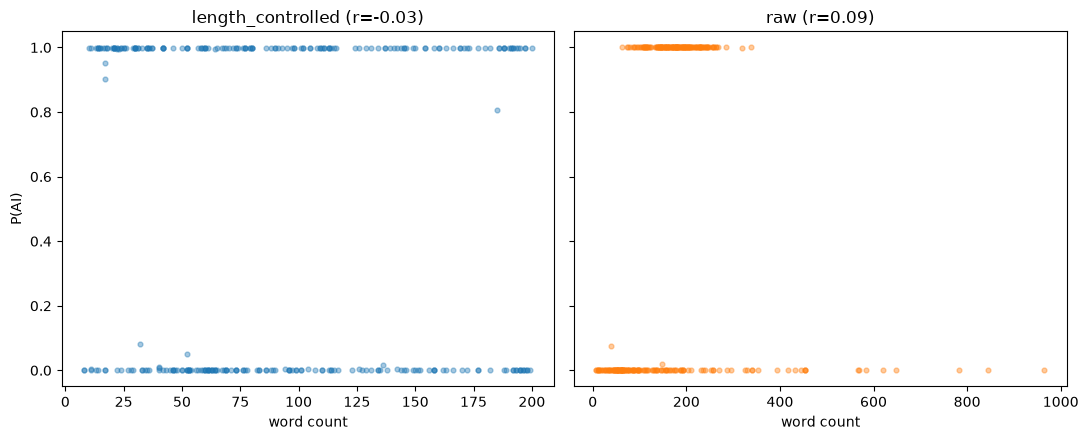

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].scatter(lc_sample['word_count'], lc_sample['p_ai'], alpha=0.4, s=12)
axes[0].set_title(f'length_controlled (r={lc_corr:.2f})')
axes[0].set_xlabel('word count')
axes[0].set_ylabel('P(AI)')

axes[1].scatter(raw_sample['word_count'], raw_sample['p_ai'], alpha=0.4, s=12, color='tab:orange')
axes[1].set_title(f'raw (r={raw_corr:.2f})')
axes[1].set_xlabel('word count')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'results' / 'figures' / 'length_shortcut_correlation.png', dpi=150)
plt.show()